# Лабораторна робота №8: Асоціативні правила та алгоритм Apriori у Python
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)  
**Студент:** Багрій-Белз Андрій, група КН-2327Б  

### Мета роботи
Дослідити алгоритм пошуку асоціативних правил Apriori (Market Basket Analysis), виконати передобробку транзакційних даних, видобути стійкі шаблони покупок за критеріями Support, Confidence та Lift, і побудувати візуалізації зв'язків.

## 1. Імпорт бібліотек та перевірка середовища

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Підключення локального модуля apriori
sys.path.append('.')
import apriori

print('Усі необхідні бібліотеки успішно імпортовано.')

Усі необхідні бібліотеки успішно імпортовано.


## 2. Завантаження транзакційних даних та очищення від пропусків
Зчитуємо файл `Basket_data.csv` без заголовків (`header=None`). Перетворюємо датасет на компактний список списків транзакцій, вилучаючи порожні значення `NaN` та пропуски.

In [2]:
df = pd.read_csv('Basket_data.csv', header=None)

transactions = []
for i in range(len(df)):
    row = [str(x).strip() for x in df.iloc[i].values if pd.notna(x) and str(x).strip() != '' and str(x).strip().lower() != 'nan']
    if row:
        transactions.append(row)

all_items = [item for sub in transactions for item in sub]
unique_items = sorted(list(set(all_items)))

print(f'Форма вхідного датасету: {df.shape}')
print(f'Кількість валідних транзакцій: {len(transactions)}')
print(f'Загальна кількість куплених одиниць товарів: {len(all_items)}')
print(f'Кількість унікальних найменувань товарів: {len(unique_items)}')
print(f'Середня кількість товарів у чеку: {len(all_items) / len(transactions):.2f}')

Форма вхідного датасету: (7501, 20)
Кількість валідних транзакцій: 7501
Загальна кількість куплених одиниць товарів: 29363
Кількість унікальних найменувань товарів: 119
Середня кількість товарів у чеку: 3.91


## 3. Навчання та генерація асоціативних правил за алгоритмом Apriori
Встановлюємо гіперпараметри згідно з завданням:
- `min_support = 0.003` (товар/набір зустрічається щонайменше у 23 транзакціях з 7501);
- `min_confidence = 0.2` (достовірність правила не менше 20%);
- `min_lift = 3.0` (підйом > 3.0 сигналізує про сильний синергетичний зв'язок між антецедентом і консеквентом);
- `max_length = 3` (розглядаємо пари та трійки товарів).

In [3]:
results = list(apriori.apriori(
    transactions,
    min_support=0.003,
    min_confidence=0.2,
    min_lift=3.0,
    max_length=3
))

rules_list = []
for record in results:
    for stat in record.ordered_statistics:
        base = sorted(list(stat.items_base))
        add = sorted(list(stat.items_add))
        if not base or not add:
            continue
        rules_list.append({
            'rule': f"{', '.join(base)} -> {', '.join(add)}",
            'base': ', '.join(base),
            'add': ', '.join(add),
            'support': float(record.support),
            'confidence': float(stat.confidence),
            'lift': float(stat.lift)
        })

rules_df = pd.DataFrame(rules_list).sort_values(by=['lift', 'confidence'], ascending=[False, False]).reset_index(drop=True)
print(f'Видобуто наборів правил (RelationRecord): {len(results)}')
print(f'Сформовано спрямованих правил: {len(rules_df)}')


Видобуто наборів правил (RelationRecord): 55
Сформовано спрямованих правил: 72


## 4. Аналіз топ-правил та збереження артефактів
Виведемо топ-10 правил з найвищим показником `lift`.

In [4]:
rules_df.head(10)

rule,base,add,support,confidence,lift
"mineral water, whole wheat pasta -> olive oil","mineral water, whole wheat pasta",olive oil,0.003866,0.402778,6.115863
fromage blanc -> honey,fromage blanc,honey,0.003333,0.245098,5.164271
"spaghetti, tomato sauce -> ground beef","spaghetti, tomato sauce",ground beef,0.003066,0.489362,4.980600
light cream -> chicken,light cream,chicken,0.004533,0.290598,4.843951
pasta -> escalope,pasta,escalope,0.005866,0.372881,4.700812
"french fries, herb & pepper -> ground beef","french fries, herb & pepper",ground beef,0.003200,0.461538,4.697422
"cereals, spaghetti -> ground beef","cereals, spaghetti",ground beef,0.003066,0.460000,4.681764
"french fries, ground beef -> herb & pepper","french fries, ground beef",herb & pepper,0.003200,0.230769,4.665768
pasta -> shrimp,pasta,shrimp,0.005066,0.322034,4.506672
"chocolate, herb & pepper -> ground beef","chocolate, herb & pepper",ground beef,0.003999,0.441176,4.490183


## 5. Візуалізація спрямованого мережевого графа зв'язків (Network Graph)
Побудова орієнтованого графа за допомогою `networkx`: вузли позначають товари / комбінації товарів, а ребра — напрямок асоціативного правила. Товщина ребер та підписи відображають силу зв'язку `lift`.

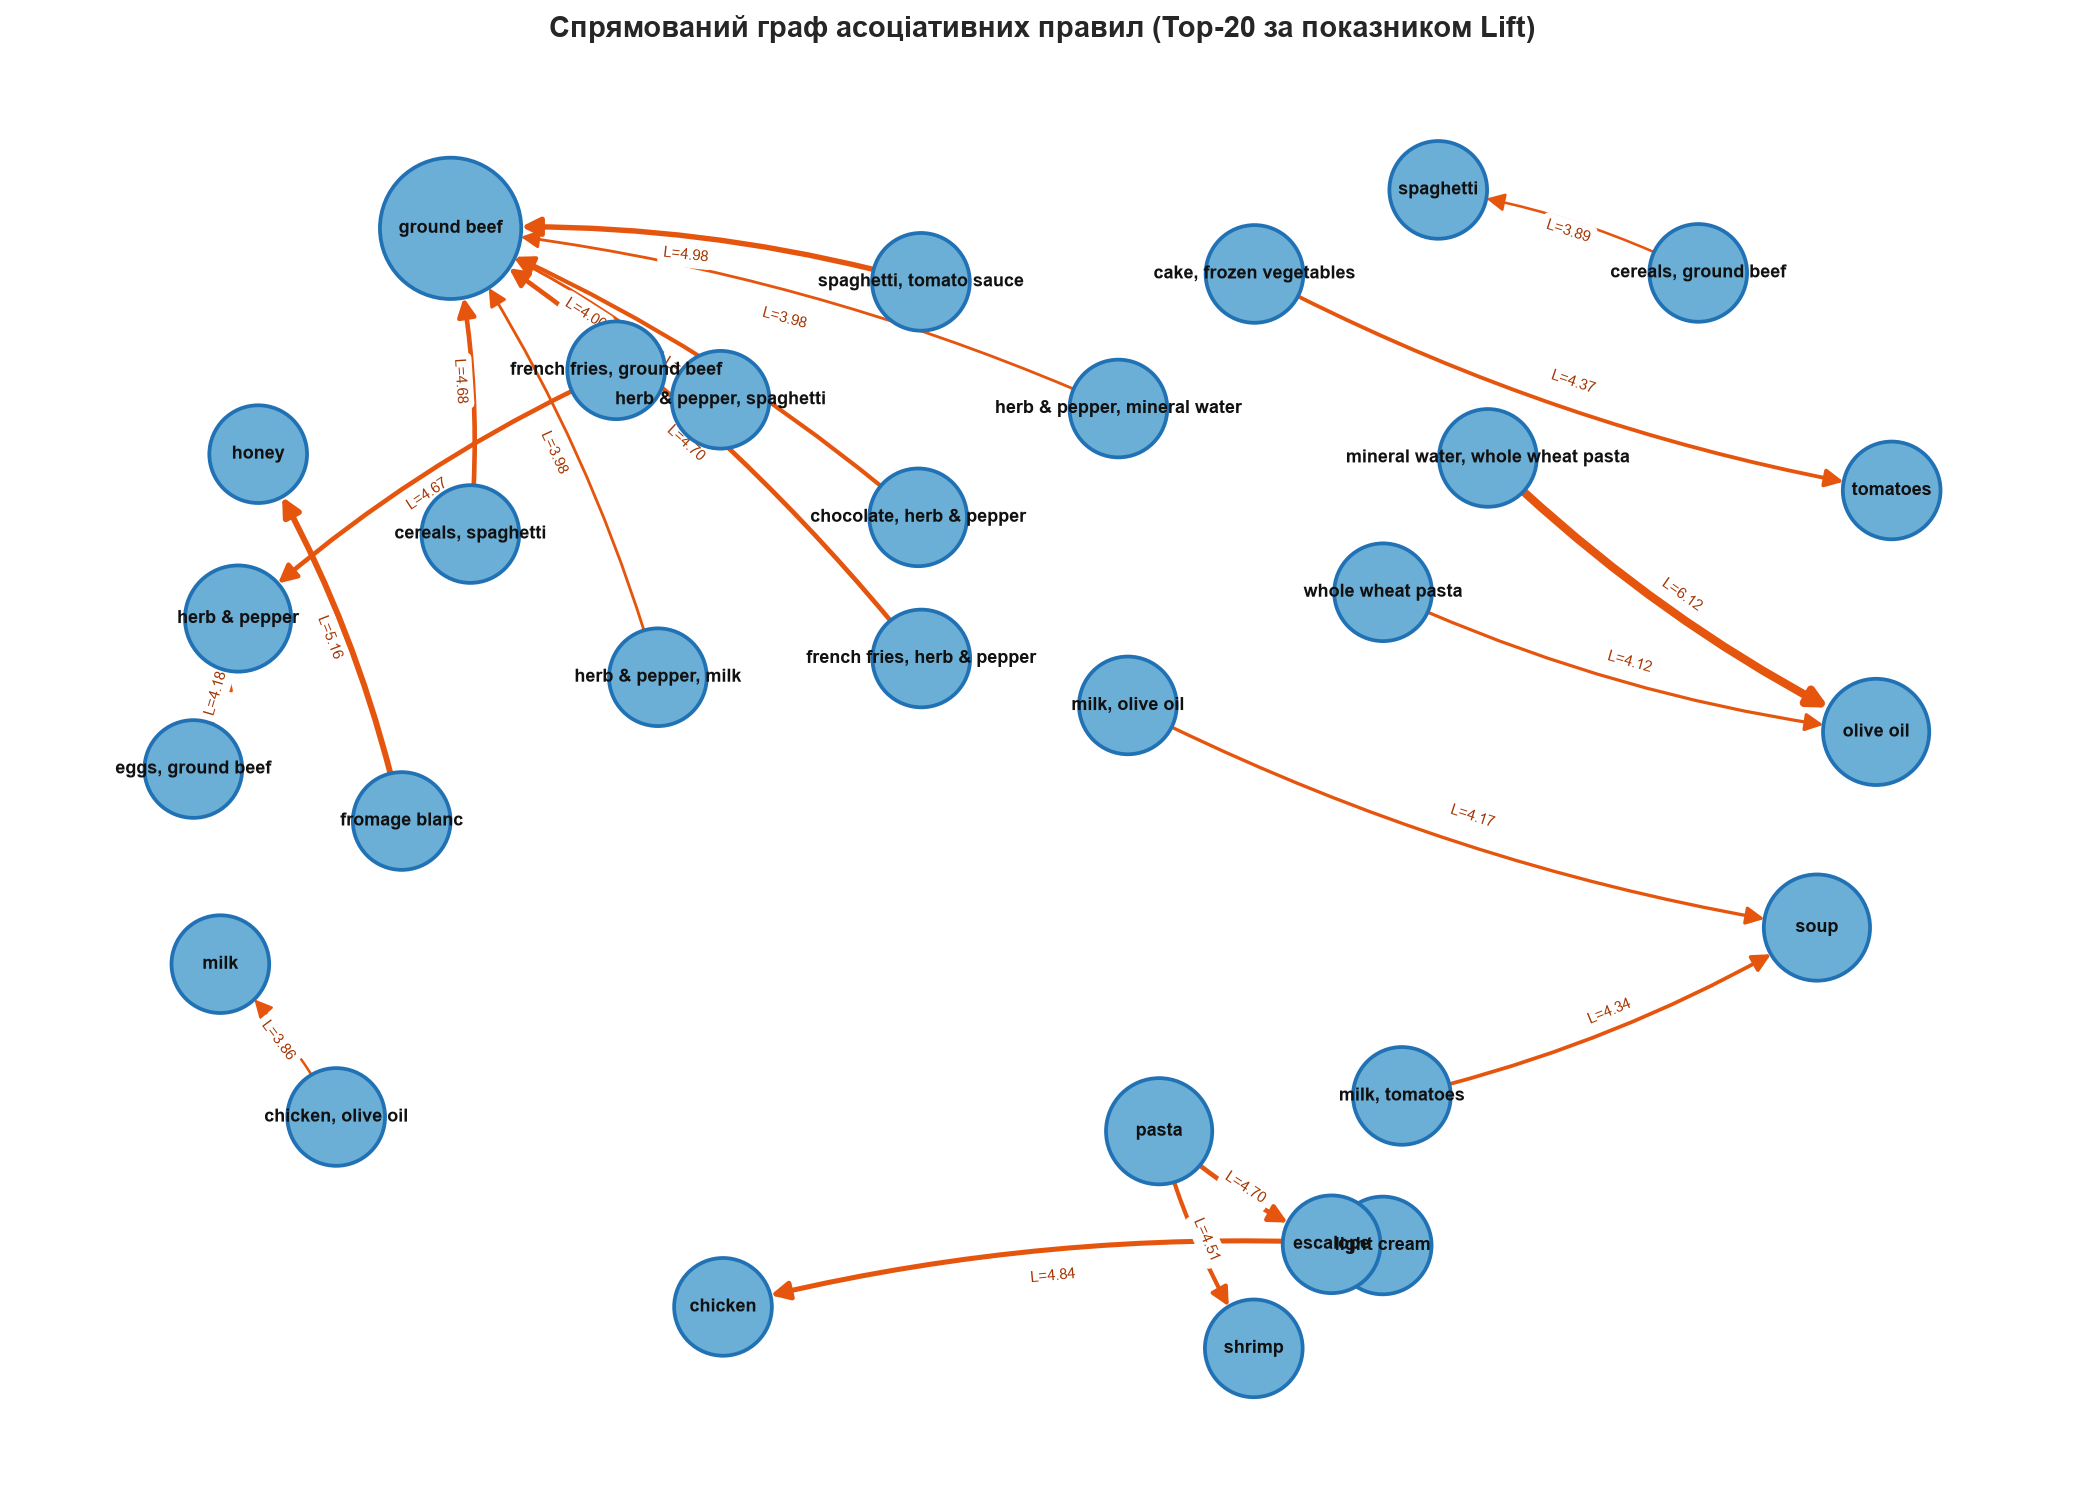

In [5]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

G = nx.DiGraph()
top_for_graph = rules_df.head(20)

for _, row in top_for_graph.iterrows():
    G.add_edge(row['base'], row['add'], weight=row['lift'], support=row['support'])

pos = nx.spring_layout(G, k=1.2, seed=42)
node_degrees = dict(G.degree())
node_sizes = [1800 + node_degrees[n] * 400 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#6baed6', edgecolors='#2171b5', linewidths=1.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, font_family='sans-serif', font_weight='bold', font_color='#111111', ax=ax)

edge_weights = [d['weight'] for _, _, d in G.edges(data=True)]
max_w, min_w = max(edge_weights), min(edge_weights)
widths = [1.2 + 2.8 * ((w - min_w) / (max_w - min_w + 1e-6)) for w in edge_weights]

nx.draw_networkx_edges(
    G, pos,
    edge_color='#e6550d',
    width=widths,
    arrows=True,
    arrowsize=18,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.08',
    node_size=node_sizes,
    ax=ax
)

edge_labels = {(u, v): f"L={d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='#a63603', ax=ax)

ax.set_title("Спрямований граф асоціативних правил (Top-20 за показником Lift)", fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Візуалізація часток підтримки (Pie Chart)
Кругова діаграма часток підтримки для топ-7 правил та узагальненої категорії 'Інші виявлені правила'.

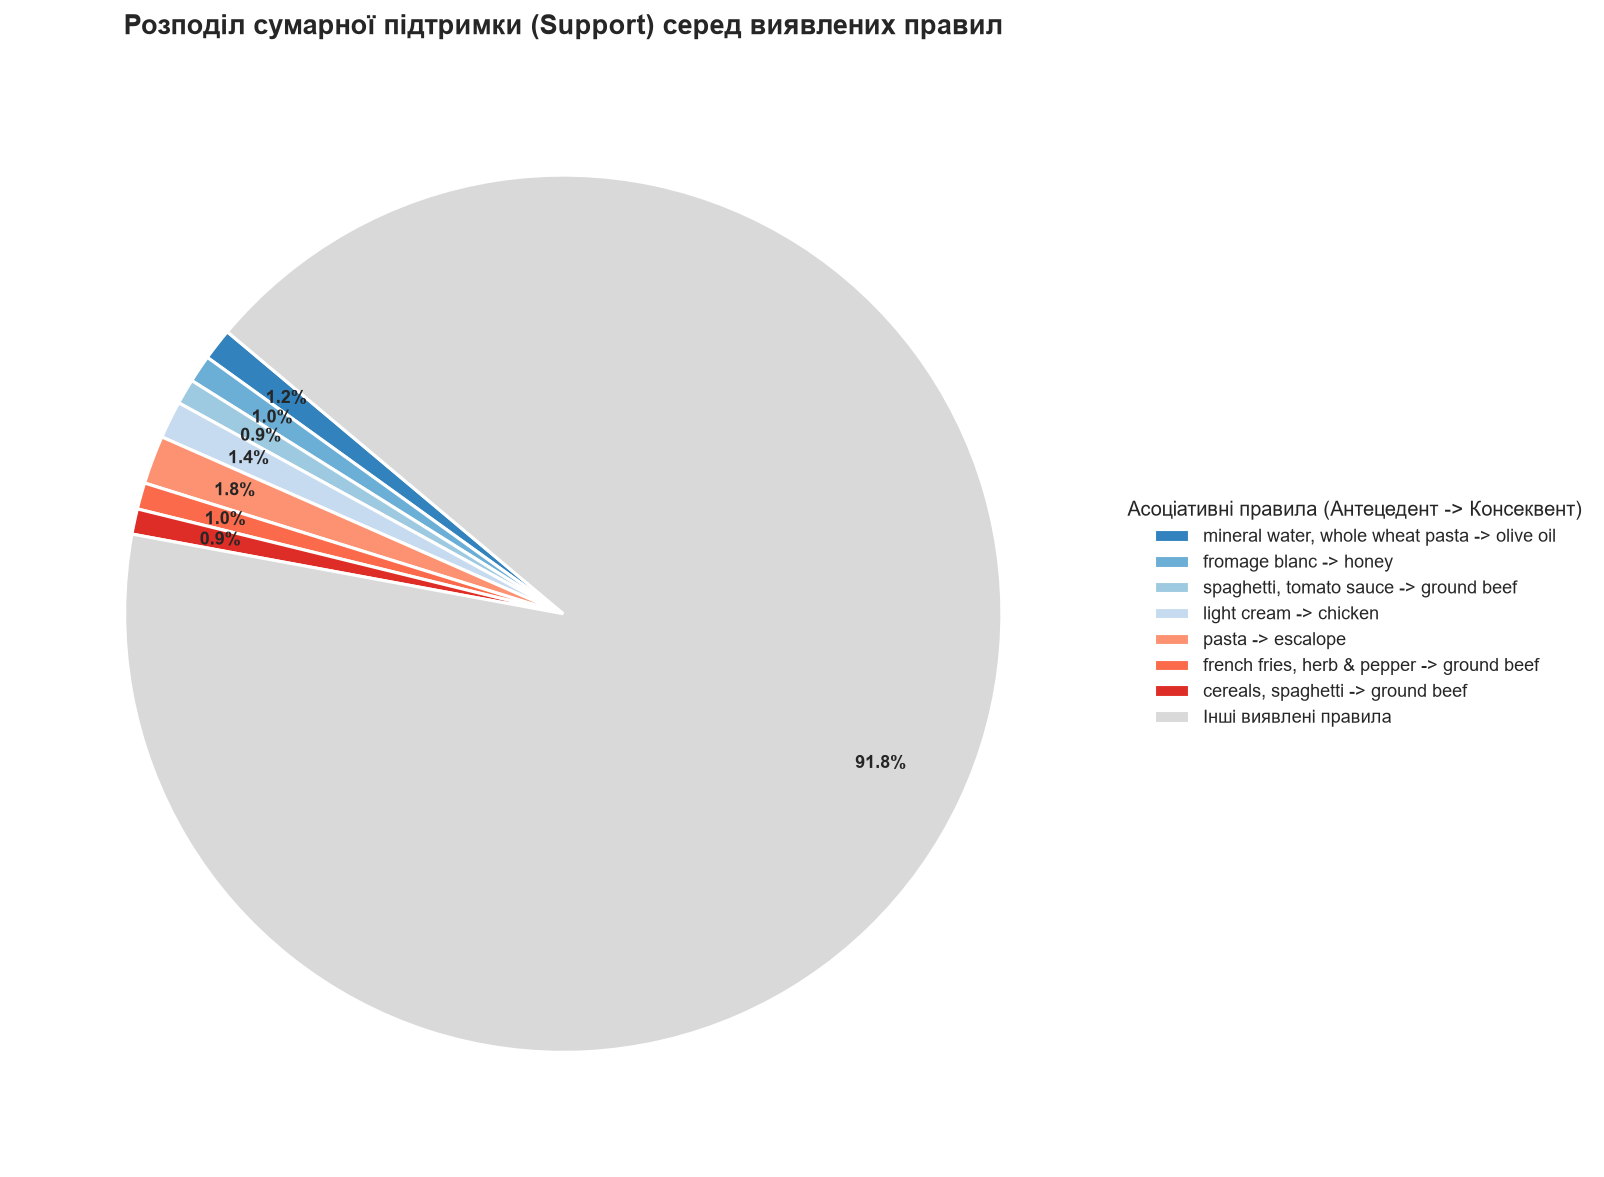

In [6]:
top_pie_rules = rules_df.head(7).copy()
other_support = rules_df.iloc[7:]['support'].sum()
pie_labels = list(top_pie_rules['rule']) + ['Інші виявлені правила']
pie_values = list(top_pie_rules['support']) + [other_support]

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
colors = ['#3182bd', '#6baed6', '#9ecae1', '#c6dbef', '#fc9272', '#fb6a4a', '#de2d26', '#d9d9d9']
wedges, texts, autotexts = ax.pie(
    pie_values,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.8,
    startangle=140,
    colors=colors,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_weight('bold')

ax.legend(
    wedges, pie_labels,
    title="Асоціативні правила (Антецедент -> Консеквент)",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=8.5,
    title_fontsize=9.5
)
ax.set_title("Розподіл сумарної підтримки (Support) серед виявлених правил", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 7. Порівняння метрик Support та Lift (Bar Chart)
Горизонтальна стовпчикова діаграма для детального зіставлення абсолютної популярності набору (`support`) та кратності приросту ймовірності спільної покупки (`lift`).

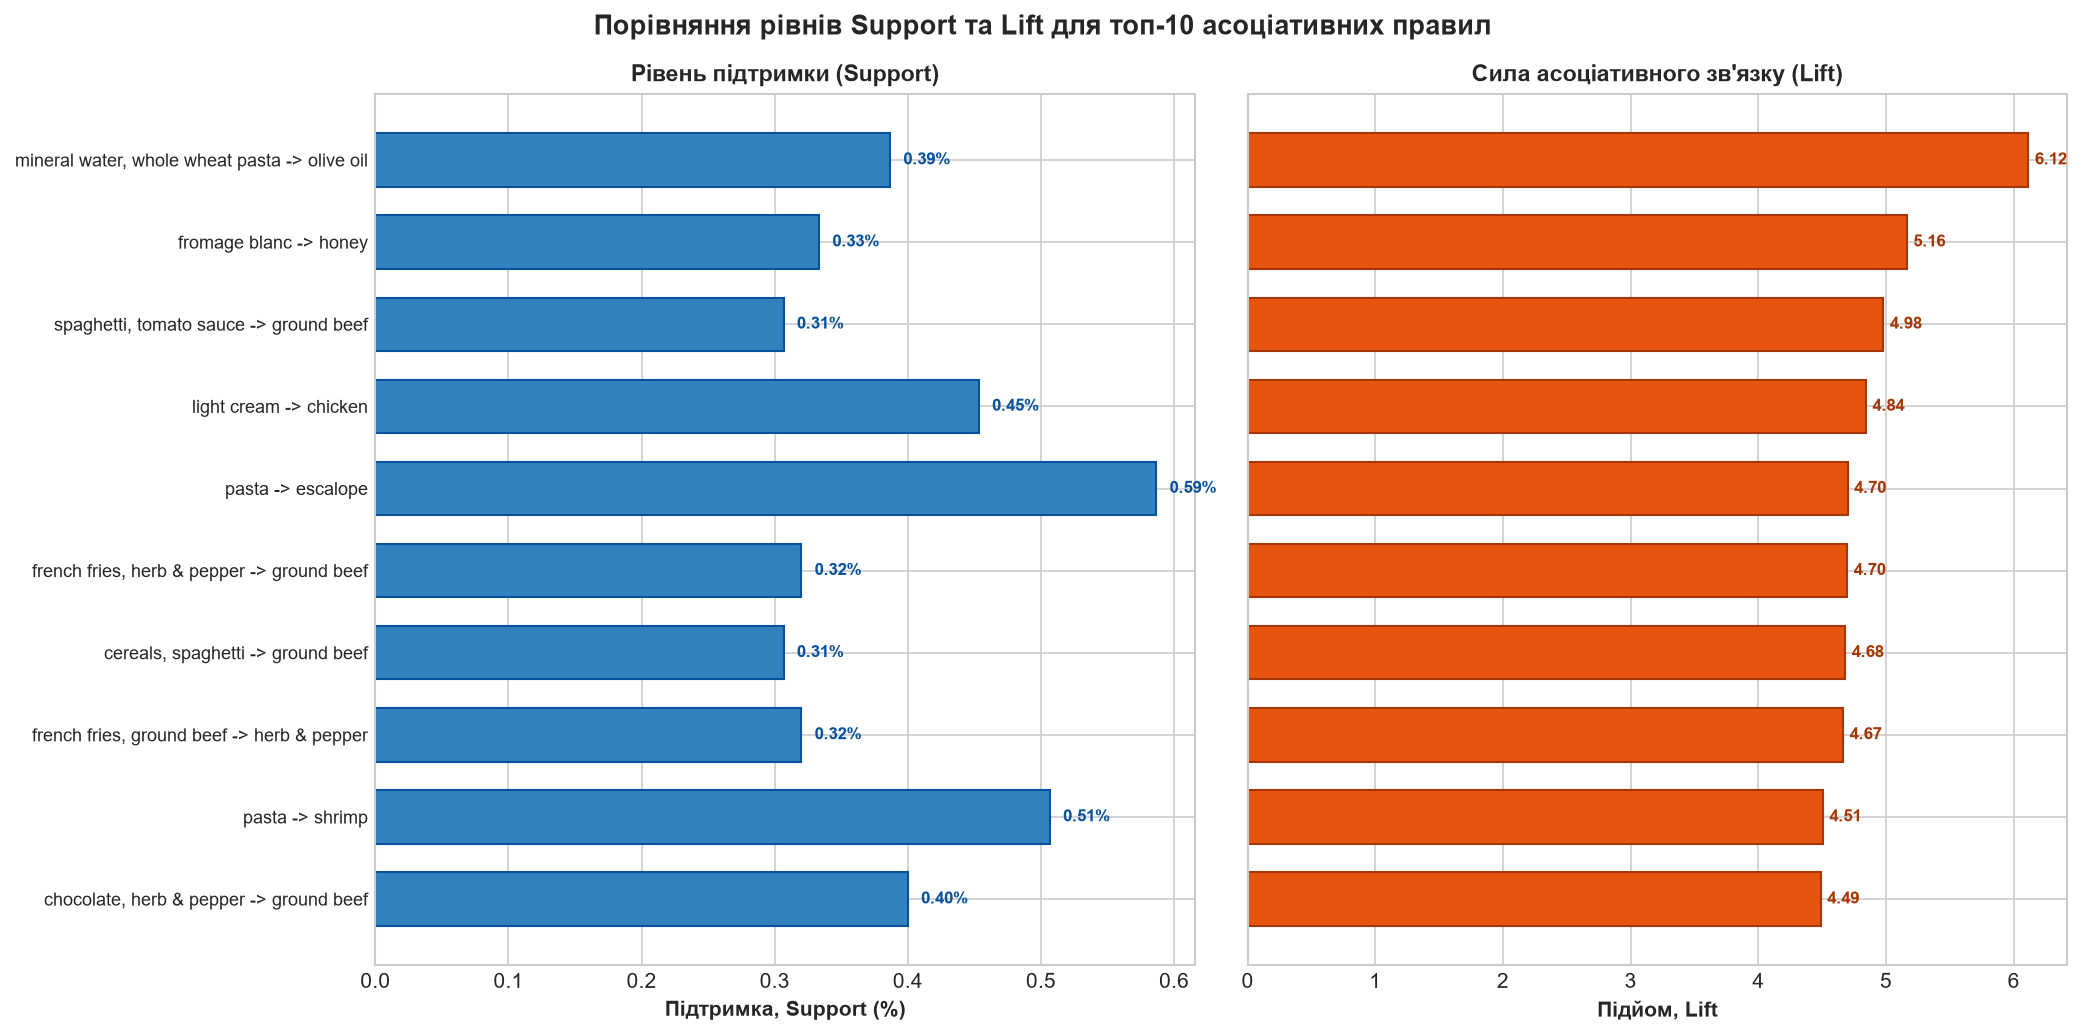

In [7]:
top10_bar = rules_df.head(10).iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), dpi=150, sharey=True)
y_indices = np.arange(len(top10_bar))
rule_labels = top10_bar['rule'].tolist()

ax1.barh(y_indices, top10_bar['support'] * 100, color='#3182bd', height=0.65, edgecolor='#08519c')
ax1.set_yticks(y_indices)
ax1.set_yticklabels(rule_labels, fontsize=8.5)
ax1.set_xlabel("Підтримка, Support (%)", fontsize=10, fontweight='bold')
ax1.set_title("Рівень підтримки (Support)", fontsize=11, fontweight='bold')
for i, v in enumerate(top10_bar['support'] * 100):
    ax1.text(v + 0.01, i, f"{v:.2f}%", va='center', fontsize=8, color='#08519c', fontweight='bold')

ax2.barh(y_indices, top10_bar['lift'], color='#e6550d', height=0.65, edgecolor='#a63603')
ax2.set_xlabel("Підйом, Lift", fontsize=10, fontweight='bold')
ax2.set_title("Сила асоціативного зв'язку (Lift)", fontsize=11, fontweight='bold')
for i, v in enumerate(top10_bar['lift']):
    ax2.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=8, color='#a63603', fontweight='bold')

fig.suptitle("Порівняння рівнів Support та Lift для топ-10 асоціативних правил", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 8. Бізнес-інтерпретація та рекомендації
- **Кулінарні зв'язки:** Правила `whole wheat pasta, mineral water -> olive oil` (Lift=6.12) та `tomato sauce, spaghetti -> ground beef` (Lift=4.98) чітко відповідають популярним рецептам середземноморської кухні (паста болоньєзе).
- **Мерчандайзинг та крос-продажі:** Доцільно розміщувати оливкову олію та томатні соуси безпосередньо поруч зі стендами макаронних виробів, або формувати комбіновані знижки («купи пасту та отримай соус/м'ясний фарш зі знижкою 15%»).
- **Делікатесні комбінації:** Зв'язок `fromage blanc -> honey` (Lift=5.16) свідчить про схильність покупців сирів до купівлі меду, що дозволяє організувати спільні дегустаційні зони у відділі молочної продукції.